In [1]:
library(readxl)
library(dplyr)
library(Seurat)
library(UCell)
library(stringr)
library(ggplot2)


载入程辑包：‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Attaching SeuratObject



In [8]:
# 1. 加载数据 (Sheet C 包含分类好的路径)
# 确保文件名与你本地一致
pathway_df <- read_excel("Human.MitoCarta3.0.xls", sheet = "C MitoPathways", col_types = "text")

# 2. 提取特定的基因集
# 提取 OXPHOS (氧化磷酸化 - 能量状态)
oxphos_genes <- pathway_df %>% 
  filter(MitoPathway == "OXPHOS") %>% 
  pull(Genes) %>% 
  strsplit(", ") %>% unlist()

# 提取 Metabolism (广义代谢 - 包含 TCA, 脂肪酸等 461 个基因)
# 修正了原代码中多出的一个 ")" 
metabolism_genes <- pathway_df %>% 
  filter(MitoPathway == "Metabolism") %>% 
  pull(Genes) %>% 
  strsplit(", ") %>% unlist()

# 提取 Mitophagy (线粒体自噬 - 评估受损清理)
mitophagy_genes <- pathway_df %>% 
  filter(MitoPathway == "Mitophagy") %>% 
  pull(Genes) %>% 
  strsplit(", ") %>% unlist()

# 提取 Dynamics (线粒体动力学 - 评估分裂/融合压力)
dynamics_genes <- pathway_df %>% 
  filter(MitoPathway == "Mitochondrial dynamics and surveillance") %>% 
  pull(Genes) %>% 
  strsplit(", ") %>% unlist()

# 补充：提取 ROS (活性氧代谢 - 最接近氧化应激的线粒体子集)
ros_genes <- pathway_df %>%
  filter(MitoPathway == "ROS and glutathione metabolism") %>%
  pull(Genes) %>%
  strsplit(", ") %>% unlist()

# 3. 构建 AUCell 列表 (建议名称保持整齐)
geneSets_list <- list(
  OXPHOS = oxphos_genes,
  Metabolism = metabolism_genes,
  Mitophagy = mitophagy_genes,
  Dynamics = dynamics_genes,
  ROS_Stress = ros_genes
)

In [9]:
# 加载小脑 RDS 文件
cerebellum <- readRDS("../cellchat/DN_celltype_res4.rds")

In [10]:
# 3. 鸽子数据适配处理 (同源性与大小写转换)
# ------------------------------------------------------------------------------
# 鸽子基因组注释常见全大写，我们将人名转大写后与数据取交集
data_genes <- rownames(cerebellum)

geneSets_cleaned <- lapply(geneSets_list, function(gs) {
  gs_upper <- toupper(gs)
  # 找出在鸽子数据中实际存在的基因
  valid <- intersect(gs_upper, toupper(data_genes))
  # 返回数据中对应的原始格式 (防止数据中是首字母大写)
  return(data_genes[toupper(data_genes) %in% valid])
})

# 打印匹配情况 (重点检查：如果长度为0说明基因名命名方式不匹配)
cat("基因集匹配统计：\n")
print(lapply(geneSets_cleaned, length))

基因集匹配统计：
$OXPHOS
[1] 90

$Metabolism
[1] 365

$Mitophagy
[1] 14

$Dynamics
[1] 86

$ROS_Stress
[1] 23



In [11]:
# 3. 运行 UCell 打分
# ------------------------------------------------------------------------------
# UCell 直接集成在 Seurat 工作流中，不需要手动转换矩阵
# ncores 可以根据你的服务器配置调整

message("Running UCell scoring...")
cerebellum <- AddModuleScore_UCell(
  obj = cerebellum,
  features = geneSets_cleaned,
  ncores = 1,                 # 如果环境依然敏感，设为1；否则可设为4或8加速
  name = "_UCell"             # 结果列名会以 _UCell 结尾
)

# 查看打分后的 MetaData 列名
# 结果通常命名为：OXPHOS_UCell, Metabolism_UCell 等
head(cerebellum@meta.data)

Running UCell scoring...



,orig.ident,nCount_RNA,nFeature_RNA,individual.id,percent.mt,percent.ribo,group,RNA_snn_res.0.01,RNA_snn_res.0.05,RNA_snn_res.0.1,⋯,RNA_snn_res.8,RNA_snn_res.9,RNA_snn_res.10,seurat_clusters,cell_type,OXPHOS_UCell,Metabolism_UCell,Mitophagy_UCell,Dynamics_UCell,ROS_Stress_UCell
,<fct>,<dbl>,<int>,<fct>,<dbl>,<dbl>,<fct>,<fct>,<fct>,<fct>,⋯,<fct>,<fct>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
WMS420-DN_AACAACACGAAATCCATTCT,WMS420-DN,1388,941,WMS420,0.7204611,0.00000000,homing,2,2,2,⋯,18,13,16,33,astrocytes,0.03648148,0.1439635,0.04814286,0.07445736,0.06066667
WMS420-DN_AACAACACGAGACCACTATT,WMS420-DN,8125,2879,WMS420,0.4307692,0.08615385,homing,0,1,1,⋯,44,68,63,16,excitatory neurons,0.03384074,0.1383836,0.08483333,0.04580620,0.07376812
WMS420-DN_AACAACACGAGCCGCAAGCG,WMS420-DN,11143,3157,WMS420,0.2333303,0.02692273,homing,1,9,11,⋯,10,115,4,13,inhibitory neurons,0.04182222,0.1426347,0.05650000,0.04491085,0.02466667
WMS420-DN_AACAACACGAGCGTAACGTC,WMS420-DN,2779,1484,WMS420,0.4677942,0.07196833,homing,0,1,1,⋯,29,29,28,12,excitatory neurons,0.05867407,0.1467589,0.05509524,0.05384109,0.04552174
WMS420-DN_AACAAGTGATACGCAGCGAA,WMS420-DN,5648,2031,WMS420,0.2124646,0.10623229,homing,0,10,12,⋯,100,109,27,18,excitatory progenitors,0.04656296,0.1423169,0.01347619,0.03354264,0.10085507
WMS420-DN_AACAAGTGATAGGTTGGCAG,WMS420-DN,2736,1445,WMS420,2.3391813,0.25584795,homing,3,4,3,⋯,77,82,84,19,oligodendrocytes,0.07221852,0.1503945,0.03145238,0.05520543,0.04873913


In [12]:
# 强制转换为因子类型（Factor）
cerebellum$cell_type <- as.factor(cerebellum$cell_type)
cerebellum$group <- as.factor(cerebellum$group)

# 检查一下是否转换成功，应该显示 "Factor w/ 16 levels" 之类的
class(cerebellum$cell_type)

[1] "factor"

In [13]:
# 4. 统计与可视化
# ------------------------------------------------------------------------------
# 绘制翻翻鸽 vs 信鸽在小脑 Purkinje 细胞中的 OXPHOS 水平
# 1. 强制关闭所有可能卡住的设备
while (!is.null(dev.list())) dev.off()

pdf("FINAL_TEST_PLOT.pdf", width = 12, height = 7)
# 修改为你数据中实际的列名（UCell 默认会去掉横杠或特殊字符）
VlnPlot(cerebellum, 
        features = "OXPHOS_UCell", 
        group.by = "cell_type", 
        split.by = "group", 
        split.plot = TRUE,
        pt.size = 0)
dev.off()

The default behaviour of split.by has changed.
Separate violin plots are now plotted side-by-side.
To restore the old behaviour of a single split violin,
set split.plot = TRUE.
      
This message will be shown once per session.

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


In [14]:
# 批量导出所有通路的对比图
pathways <- c("OXPHOS_UCell", "Metabolism_UCell", "Mitophagy_UCell", "Dynamics_UCell", "ROS_Stress_UCell")

for(pw in pathways){
  p <- VlnPlot(cerebellum, features = pw, group.by = "cell_type", split.by = "group", pt.size = 0) +
       theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
       labs(title = paste("Pathway Analysis:", pw))
  
  # 打印到屏幕
  grid::grid.draw(p)
  
  # 保存到本地
  ggsave(paste0("Comparison_", pw, ".pdf"), plot = p, width = 10, height = 6, dpi = 300)
}

In [15]:
unique(cerebellum@meta.data$cell_type)

[1] astrocytes                     excitatory neurons            
 [3] inhibitory neurons             excitatory progenitors        
 [5] oligodendrocytes               endothelial                   
 [7] vasculature-associated cells   microglia                     
 [9] red blood cells                Oligodendrocyte precursor cell
[11] inhibitory progenitors        
11 Levels: Oligodendrocyte precursor cell astrocytes ... vasculature-associated cells

In [16]:
library(ggpubr)
library(rstatix) # 方便进行批量校正

pathways <- c("OXPHOS_UCell", "Metabolism_UCell", "Mitophagy_UCell", "Dynamics_UCell", "ROS_Stress_UCell")

for(pw in pathways){
  if(!pw %in% colnames(cerebellum@meta.data)) next

  # 1. 提取数据
  plot_data <- FetchData(cerebellum, vars = c(pw, "cell_type", "group"))
  plot_data$cell_type <- trimws(plot_data$cell_type) # 清理空格

  p <- ggplot(plot_data, aes(x = cell_type, y = .data[[pw]], fill = group)) +
       # 1. 基础小提琴图和箱线图 (保持不变)
       geom_violin(scale = "width", adjust = 1, trim = TRUE, 
                   position = position_dodge(width = 0.9), alpha = 0.8) +
       geom_boxplot(width = 0.1, color = "black", outlier.shape = NA, 
                    position = position_dodge(width = 0.9)) +
       
       # =============================================================
       # 核心修改点：添加统计检验标记
       # method = "wilcox.test" (对应你的 Wilcoxon Test)
       # label = "p.signif" (显示 ns, *, **, ***)
       # =============================================================
       stat_compare_means(
         aes(group = group), 
         method = "wilcox.test", 
         label = "p.signif", 
         label.y = max(plot_data[[pw]]) + 0.02, # 自动调整标签高度
         hide.ns = FALSE                       # 是否隐藏 'ns' (建议显示)
       ) +
       
       # 2. 主题和样式 (保持不变，或微调颜色)
       theme_bw() +
       theme(
         axis.text.x = element_text(angle = 45, hjust = 1),
         panel.grid.major = element_blank(),
         panel.grid.minor = element_blank()
       ) +
       scale_fill_manual(values = c("homing" = "#4DBBD5FF", "tumbler" = "#E64B35FF")) +
       labs(title = paste("Pathway Analysis:", pw), 
            subtitle = "Statistics: Wilcoxon Test (ggpubr automatic)",
            y = "UCell Score", x = "Cell Cluster")

  # 4. 导出
  filename <- paste0("Comparison_with_Padj_", pw, ".pdf")
  ggsave(filename, plot = p, width = 14, height = 7, dpi = 300)
}


载入程辑包：‘rstatix’


The following object is masked from ‘package:stats’:

    filter




In [17]:
library(tidyverse)

# 1. 初始化列表存储结果
summary_stats <- list()

message("正在量化各细胞类型的差异程度...")

for(pw in pathways){
  if(!pw %in% colnames(cerebellum@meta.data)) next
  
  # 提取当前通路数据
  data_tmp <- FetchData(cerebellum, vars = c(pw, "cell_type", "group"))
  data_tmp$cell_type <- trimws(data_tmp$cell_type)
  
  # 计算每个 cluster 的统计量
  res <- data_tmp %>%
    group_by(cell_type) %>%
    # 确保两组都有细胞，否则无法比较
    filter(n_distinct(group) == 2) %>% 
    summarise(
      Pathway = pw,
      # 计算均值
      Mean_Homing = mean(.data[[pw]][group == "homing"]),
      Mean_Tumbler = mean(.data[[pw]][group == "tumbler"]),
      # 计算 Log2 Fold Change (Tumbler / Homing)
      Log2FC = log2(Mean_Tumbler / Mean_Homing),
      # 计算 Wilcoxon P值
      P_Val = wilcox.test(.data[[pw]] ~ group)$p.value,
      .groups = 'drop'
    )
  
  summary_stats[[pw]] <- res
}

# 2. 合并并计算校正后的 P 值 (FDR/BH)
df_plot <- bind_rows(summary_stats) %>%
  mutate(Padj = p.adjust(P_Val, method = "BH")) %>%
  mutate(neg_logP = -log10(Padj + 1e-10)) # 用于绘图点的大小

# 保存统计结果到 Excel
# openxlsx::write.xlsx(df_plot, "Pathway_Difference_Quantification.xlsx")

正在量化各细胞类型的差异程度...



Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


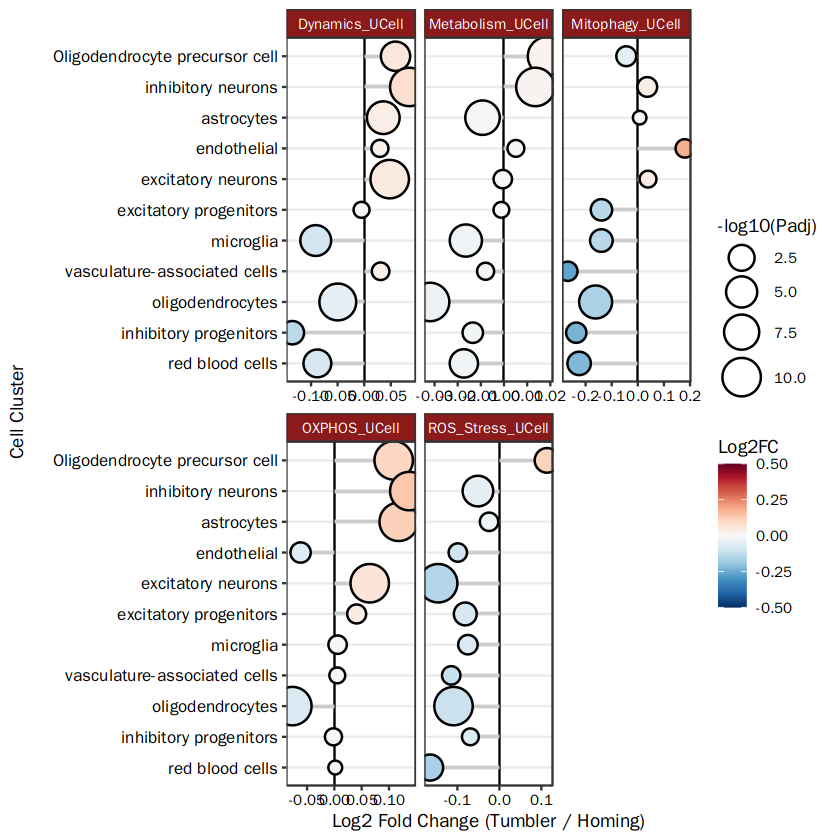

In [18]:
# 重新定义绘图对象，重点修改颜色部分
p_quant_v2 <- ggplot(df_plot, aes(x = Log2FC, y = reorder(cell_type, Log2FC))) +
  geom_vline(xintercept = 0, linetype = "solid", color = "black", size = 0.5) +
  geom_segment(aes(yend = cell_type, xend = 0), color = "grey80", size = 0.8) +
  
  # 增加 stroke 让黑边更明显，提高立体感
  geom_point(aes(size = neg_logP, fill = Log2FC), shape = 21, color = "black", stroke = 0.8) +
  
  # 关键修改：oob = scales::squish 会把超出范围的颜色强制显示为最深色
  # 这样可以让 0.2 这种小差异也显示出明显的颜色
  scale_fill_gradientn(
    colors = rev(RColorBrewer::brewer.pal(11, "RdBu")), 
    limits = c(-0.5, 0.5), # 强制将颜色范围限制在 -0.5 到 0.5，超出部分显示最深红/深蓝
    oob = scales::squish,
    name = "Log2FC"
  ) +
  
  scale_size_continuous(range = c(3, 10), name = "-log10(Padj)") +
  
  facet_wrap(~Pathway, scales = "free_x", ncol = 3) +
  theme_bw() +
  theme(
    axis.text.y = element_text(size = 10, color = "black", face = "bold"),
    axis.text.x = element_text(color = "black"),
    strip.background = element_rect(fill = "firebrick4"), # 换成深红色标题框
    strip.text = element_text(color = "white", face = "bold"),
    panel.grid.major.x = element_blank(),
    panel.grid.minor = element_blank()
  ) +
  labs(x = "Log2 Fold Change (Tumbler / Homing)", y = "Cell Cluster")

print(p_quant_v2)

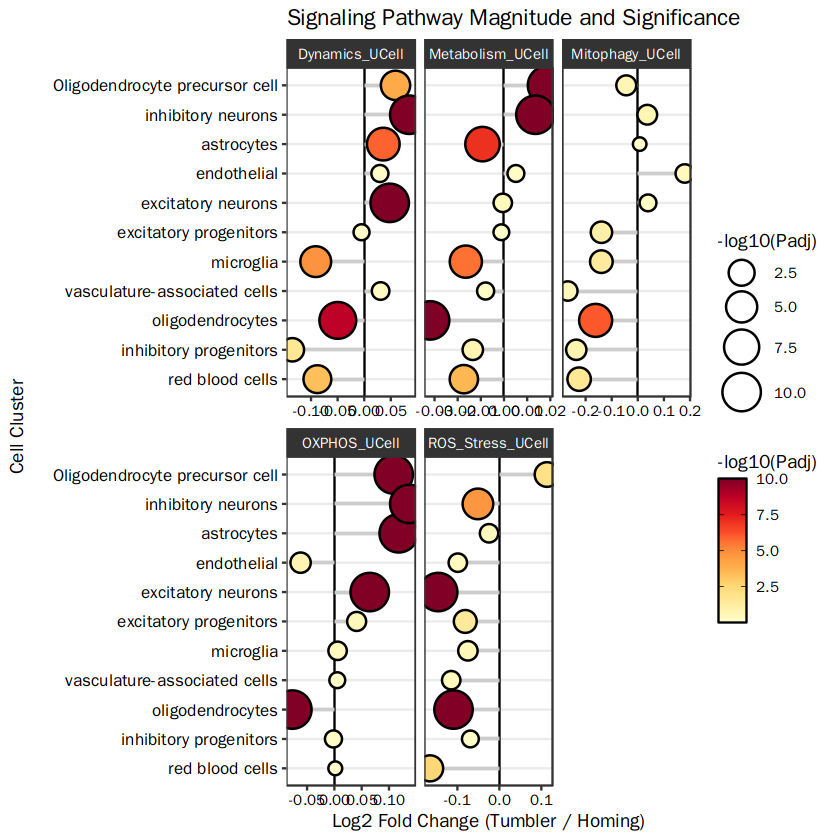

In [19]:
# 重新定义绘图对象：颜色映射改为显著性 (-log10 Padj)
p_quant_v3 <- ggplot(df_plot, aes(x = Log2FC, y = reorder(cell_type, Log2FC))) +
  geom_vline(xintercept = 0, linetype = "solid", color = "black", size = 0.5) +
  geom_segment(aes(yend = cell_type, xend = 0), color = "grey80", size = 0.8) +
  
  # 颜色映射改为 neg_logP，点的大小可以继续保留显著性，或者改为别的度量
  geom_point(aes(size = neg_logP, fill = neg_logP), shape = 21, color = "black", stroke = 0.8) +
  
  # 颜色比例尺修改：使用单色渐变，越红代表越显著
  scale_fill_gradientn(
    colors = RColorBrewer::brewer.pal(9, "YlOrRd"), 
    name = "-log10(Padj)",
    guide = guide_colorbar(frame.colour = "black", ticks.colour = "black")
  ) +
  
  scale_size_continuous(range = c(3, 10), name = "-log10(Padj)") +
  
  facet_wrap(~Pathway, scales = "free_x", ncol = 3) +
  theme_bw() +
  theme(
    axis.text.y = element_text(size = 10, color = "black", face = "bold"),
    axis.text.x = element_text(color = "black"),
    # 标题框颜色可以根据文章风格调整，这里保留深红色或改为深蓝色
    strip.background = element_rect(fill = "grey20"), 
    strip.text = element_text(color = "white", face = "bold"),
    panel.grid.major.x = element_blank(),
    panel.grid.minor = element_blank(),
    legend.position = "right"
  ) +
  labs(
    x = "Log2 Fold Change (Tumbler / Homing)", 
    y = "Cell Cluster",
    title = "Signaling Pathway Magnitude and Significance"
  )

print(p_quant_v3)

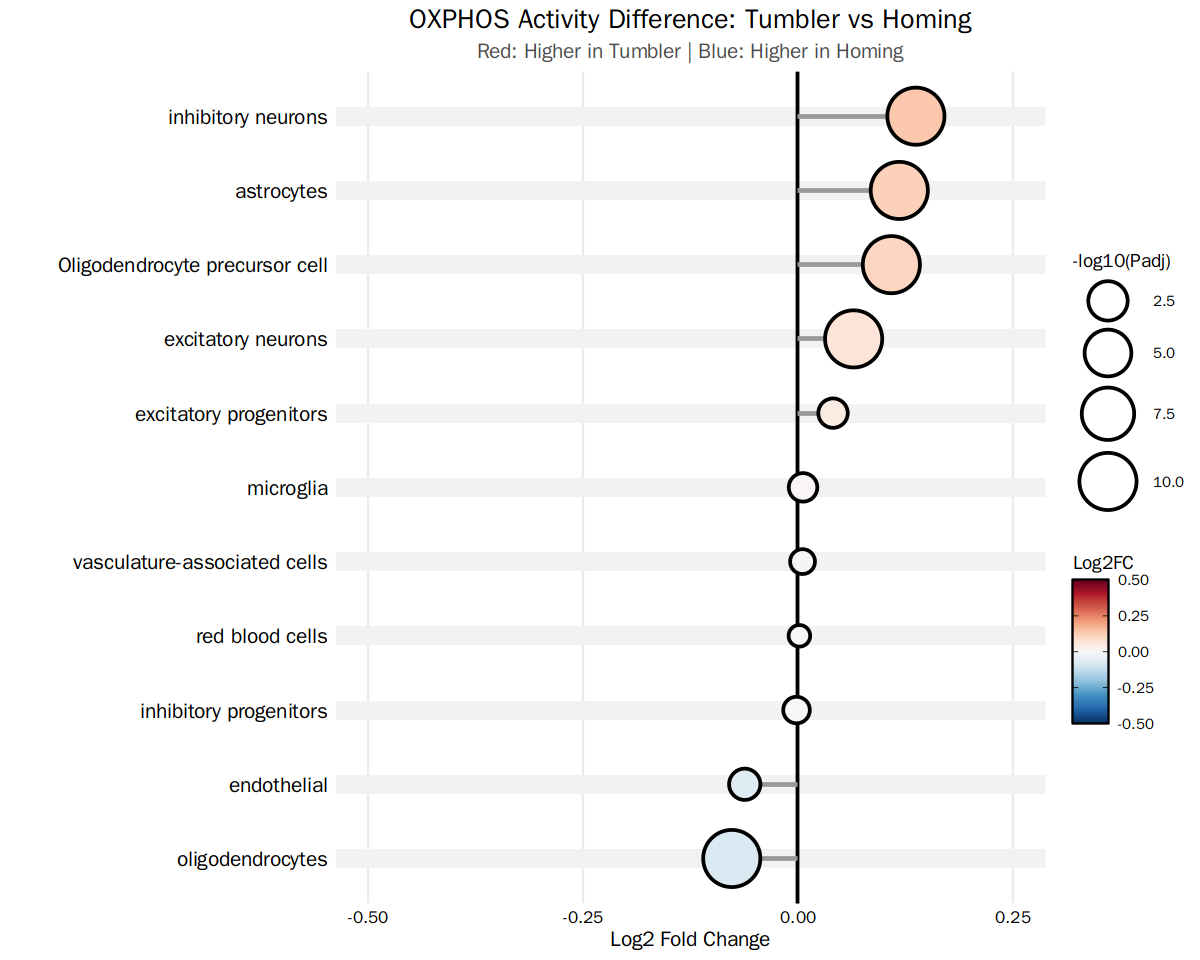

In [22]:
options(repr.plot.width = 10, repr.plot.height = 8)
library(ggplot2)
library(scales)
library(RColorBrewer)

# 1. 筛选 OXPHOS 数据并清理
df_oxphos <- df_plot %>% 
  filter(Pathway == "OXPHOS_UCell") %>%
  mutate(cell_type = trimws(cell_type))

# 2. 绘制高对比度棒棒糖图
p_oxphos <- ggplot(df_oxphos, aes(x = Log2FC, y = reorder(cell_type, Log2FC))) +
  # 添加背景带，交替颜色增加可读性
  geom_hline(yintercept = seq_along(unique(df_oxphos$cell_type)), color = "grey95", size = 4) +
  # 强化中心零线
  geom_vline(xintercept = 0, linetype = "solid", color = "black", size = 0.8) +
  # 强化连接线
  geom_segment(aes(yend = cell_type, xend = 0), color = "grey60", size = 1) +
  
  # 绘制气泡：shape=21带边框，stroke增加边框厚度
  geom_point(aes(size = neg_logP, fill = Log2FC), shape = 21, color = "black", stroke = 1.2) +
  
  # 颜色映射：极限压缩到 -0.2 到 0.2
  # 这样微小的生物学差异在视觉上也会非常震撼
  scale_fill_gradientn(
    colors = rev(brewer.pal(11, "RdBu")), 
    limits = c(-0.5, 0.5), 
    oob = squish,
    guide = guide_colorbar(frame.colour = "black", ticks.colour = "black", barwidth = 1.5)
  ) +
  
  # 放大气泡尺寸范围
  scale_size_continuous(range = c(5, 15), name = "-log10(Padj)") +

  coord_cartesian(xlim = c(-0.5, 0.25))+
  
  theme_minimal() + # 使用极简主题突出数据
  labs(
    title = "OXPHOS Activity Difference: Tumbler vs Homing",
    subtitle = "Red: Higher in Tumbler | Blue: Higher in Homing",
    x = "Log2 Fold Change",
    y = ""
  ) +
  theme(
    # 显著加粗加黑纵轴文字
    axis.text.y = element_text(size = 12, color = "black", face = "bold"),
    axis.text.x = element_text(size = 10, color = "black", face = "bold"),
    axis.title.x = element_text(size = 12, face = "bold"),
    # 移除多余网格线
    panel.grid.major.y = element_blank(),
    panel.grid.minor = element_blank(),
    plot.title = element_text(size = 16, face = "bold", hjust = 0.5),
    plot.subtitle = element_text(size = 12, hjust = 0.5, color = "grey30"),
    legend.position = "right",
    legend.title = element_text(face = "bold")
  )

# 打印查看
print(p_oxphos)

dir.create("plots", showWarnings = FALSE)

outfile_pdf <- file.path(getwd(), "plots", "OXPHOS_lollipop.pdf")
outfile_png <- file.path(getwd(), "plots", "OXPHOS_lollipop.png")

ggsave(outfile_pdf, plot = p_oxphos, device = "pdf", width = 10, height = 8, units = "in")
ggsave(outfile_png, plot = p_oxphos, width = 10, height = 8, dpi = 300, units = "in")